# Score matching

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import tqdm
from sklearn.datasets import make_swiss_roll

## Datos de entrenamiento

In [2]:
def get_batch(batch_size=100, noise=0.1):
    x, _ = make_swiss_roll(batch_size, noise=noise)
    x = x[:, [0, 2]]
    x = (x - x.mean()) / x.std()
    return torch.tensor(x).float()

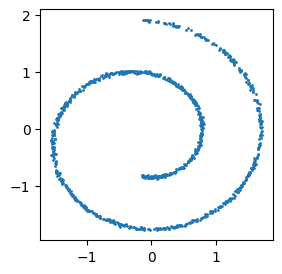

In [3]:
samples = get_batch(batch_size=1000)
plt.figure(figsize=(3, 3))
plt.scatter(samples[:, 0], samples[:, 1], s=1)
plt.show()

## Clase `SM`

In [4]:
class SM:

    @staticmethod
    def train_model(net, optimizer, dsm, n_iters):

        for _ in tqdm.trange(n_iters):

            x = get_batch()

            # ---------------- Cálculo de loss ----------------

            # Denoising score matching.
            if dsm:
                sigma = 0.1
                x_bar = x + sigma * torch.randn_like(x)
                score = net(x_bar)
                inner = (x - x_bar) / sigma**2 - score
                loss =  1/2 * (torch.linalg.norm(inner, dim=-1) ** 2).mean()
            
            # Score matching.
            else:
                score = net(x)
                score_norm = 1/2 * torch.linalg.norm(score, dim=-1) ** 2
                jacobian = torch.vmap(torch.func.jacrev(net))(x)
                jacobian_trace = torch.vmap(torch.trace)(jacobian)
                loss = (score_norm + jacobian_trace).mean()

            # ---------------- Optimización ----------------
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    @staticmethod
    def generate_samples(net, n_samples, step_size=0.001, n_steps=1000):
        
        with torch.no_grad():
            x = torch.rand((n_samples, 2))
            for _ in range(n_steps):
                epsilon = torch.randn_like(x)
                x = x + step_size * net(x) + (2 * step_size) ** 0.5 * epsilon
            return x

## Red neuronal

In [5]:
class ScoreNetwork(nn.Module):

    def __init__(self, data_dim):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(data_dim, 64), nn.LogSigmoid(),
            nn.Linear(64, 64), nn.LogSigmoid(),
            nn.Linear(64, 64), nn.LogSigmoid(),
            nn.Linear(64, data_dim)
        )

    def forward(self, x):
        return self.mlp(x)

## Entrenamiento

### Entrenamiento para DSM

100%|██████████| 30000/30000 [00:17<00:00, 1675.96it/s]


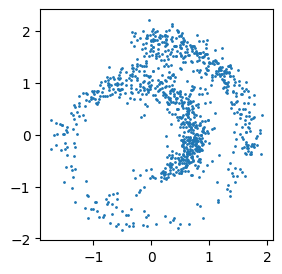

In [6]:
# Entrenamiento:
dsm_net = ScoreNetwork(data_dim=2)
dsm_optimizer = optim.Adam(dsm_net.parameters(), lr=3e-4)
SM.train_model(dsm_net, dsm_optimizer,dsm=True, n_iters=30000)

# Generación de muestras:
dsm_samples = SM.generate_samples(dsm_net, n_samples=1000)
plt.figure(figsize=(3, 3))
plt.scatter(dsm_samples[:, 0], dsm_samples[:, 1], s=1)
plt.show()

### Entrenamiento para SM

100%|██████████| 30000/30000 [00:46<00:00, 643.76it/s]


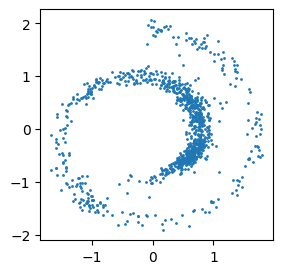

In [7]:
# Entrenamiento:
sm_net = ScoreNetwork(data_dim=2)
sm_optimizer = optim.Adam(sm_net.parameters(), lr=3e-4)
SM.train_model(sm_net, sm_optimizer, dsm=False, n_iters=30000)

# Generación de muestras:
sm_samples = SM.generate_samples(sm_net, n_samples=1000)
plt.figure(figsize=(3, 3))
plt.scatter(sm_samples[:, 0], sm_samples[:, 1], s=1)
plt.show()